## Steps for the project
* Preprocess + EDA + Feature Selection
* Extract input
* Scale the values
* Train Test Split
* Train the model
* Evaluate the model/ model Selection
* Deploy the model

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("./placement.csv")

In [3]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [4]:
df = df.iloc[:,1:]
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [5]:
%matplotlib inline
import matplotlib.pyplot as plt

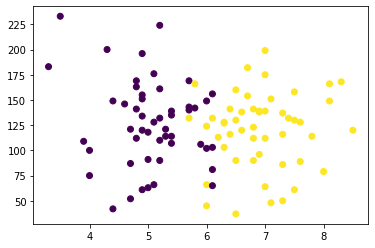

In [6]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [7]:
x = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [8]:
x.shape, y.shape

((100, 2), (100,))

## It is a simple random sampling technique

In [9]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.1)

In [10]:
x_train.shape

(90, 2)

In [11]:
x_train

,cgpa,iq
31,3.9,109.0
17,3.3,183.0
67,5.0,118.0
29,7.0,112.0
10,6.0,45.0
...,...,...
6,5.7,143.0
41,5.4,114.0
56,6.1,65.0
71,6.1,132.0


In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [13]:
x_train = scaler.fit_transform(x_train)
x_train

array([[-1.82187846, -0.42835096],
       [-2.33750444,  1.45221422],
       [-0.87656416, -0.19963357],
       [ 0.8421891 , -0.35211183],
       [-0.01718753, -2.0547857 ],
       [ 1.27187742, -1.64817702],
       [-0.96250183, -0.14880748],
       [ 0.24062546, -0.58082921],
       [-0.70468884, -0.40293791],
       [ 0.8421891 ,  0.33404033],
       [ 0.58437611,  1.42680118],
       [-1.04843949, -0.35211183],
       [ 1.10000209, -1.01285094],
       [-0.87656416, -1.59735093],
       [ 0.67031377, -0.07256836],
       [-0.96250183, -1.64817702],
       [-0.01718753, -1.5211118 ],
       [-0.61875117, -0.12339444],
       [ 1.10000209, -0.25045966],
       [ 1.18593975,  0.15614903],
       [-0.53281351,  0.23238816],
       [ 0.92812676,  0.63899685],
       [-0.01718753, -0.04715531],
       [ 1.10000209,  0.28321425],
       [ 0.49843845,  0.30862729],
       [ 1.78750339,  1.02019249],
       [-1.13437715, -1.8768944 ],
       [-0.7906265 ,  1.27432292],
       [ 1.27187742,

In [14]:
x_test = scaler.transform(x_test)

In [15]:
from sklearn.linear_model import LogisticRegression

In [16]:
model = LogisticRegression()

In [17]:
model.fit(x_train,y_train)

LogisticRegression()

In [18]:
model.predict(x_test)

array([0, 0, 0, 0, 0, 0, 1, 1, 1, 1])

In [19]:
y_test

12    0
25    0
89    0
9     0
86    0
28    0
78    0
79    1
91    1
82    1
Name: placement, dtype: int64

In [20]:
y_pred = model.predict(x_test)

In [21]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test,y_pred)

0.9

###  PLotting Decision boundary

In [22]:
from mlxtend.plotting import plot_decision_regions

<AxesSubplot:>

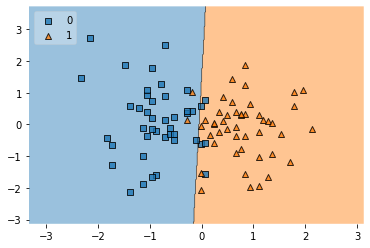

In [24]:
plot_decision_regions(x_train, y_train.values , clf=model, legend=2)

In [25]:
import pickle 

In [26]:
pickle.dump(model,open('model.pkl','wb'))